In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pe = pd.read_csv('S5ENRS_DAILY_BEST_PE.csv', index_col=0, parse_dates=True).sort_index(ascending=True).shift()[1:]
prices = pd.read_csv('S5ENRS.csv', index_col=0, parse_dates=True).sort_index(ascending=True)

pe = pe[pe.index >= '1990-01-01']
prices = prices[prices.index >= '1990-01-01']

pe = pe[pe.index.isin(prices.index)].copy()
prices = prices[prices.index.isin(pe.index)].copy()

pe = pe[:-1]
prices = prices[:-1]

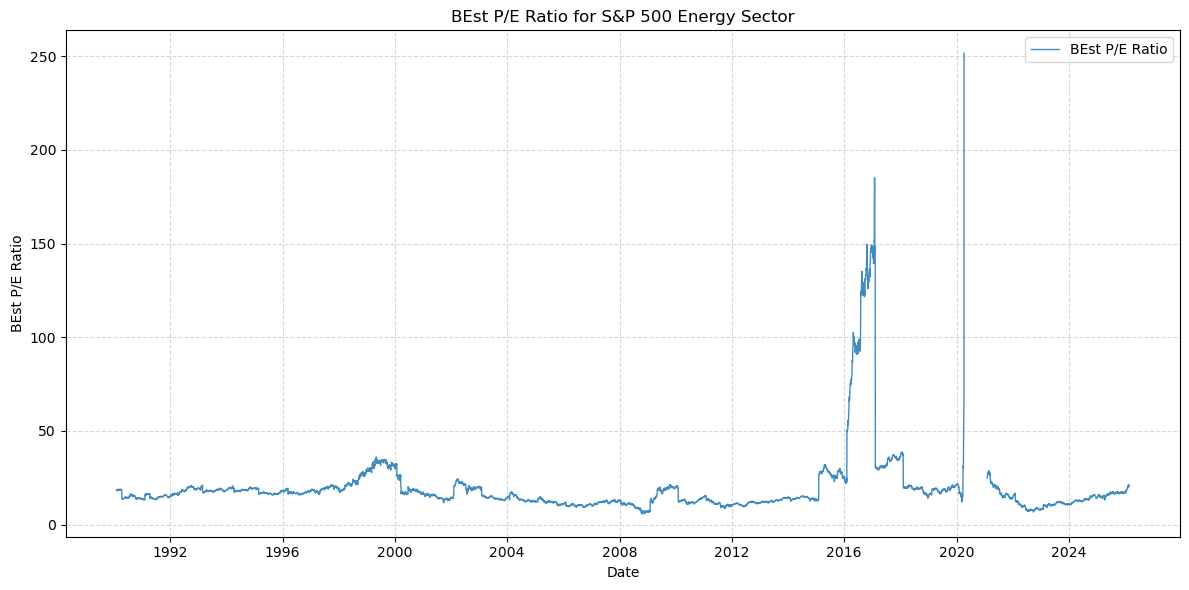

In [3]:
plt.figure(figsize=(12,6))

plt.plot(pe.index, pe['BEst P/E Ratio'], label='BEst P/E Ratio', alpha=0.85, lw=1)

plt.title('BEst P/E Ratio for S&P 500 Energy Sector')
plt.xlabel('Date')
plt.ylabel('BEst P/E Ratio')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Strategy Implementation

In [4]:
# Min-max Scaling function implementation

def rolling_minmax_df(df, window):
    roll_min = df.rolling(window=window, min_periods=window).min()
    roll_max = df.rolling(window=window, min_periods=window).max()
    return (df - roll_min) / (roll_max - roll_min)

In [5]:
energy_sector = pe[['BEst P/E Ratio']].dropna().copy()

energy_sector['price'] = prices['S5ENRS Index - Last Price'].copy()
energy_sector['Returns'] = energy_sector['price'].pct_change()

energy_sector.head()

,BEst P/E Ratio,price,Returns
Date,,,
1990-02-01,18.1207,88.231,NaN
1990-02-02,18.1192,88.887,0.007435
1990-02-05,18.2549,89.105,0.002453
1990-02-06,18.2997,88.550,-0.006229
1990-02-07,18.1857,90.137,0.017922


In [ ]:
from itertools import product

# Define parameter ranges
window_vals = np.array([252, 504, 756, 1260, 1764]) # 1yr, 2yr, 3yr, 5yr, 7yr
u1_vals = np.linspace(0.80, 0.95, 5) 
u2_vals = np.linspace(0.60, 0.79, 5)  
l2_vals = np.linspace(0.21, 0.45, 5)  
l1_vals = np.linspace(0.05, 0.20, 5)  

train_end  = '2022-12-31'
test_start = '2023-01-01'

# Strategy function
def run_strategy(sector, window, u1, u2, l1, l2):
    transformed = rolling_minmax_df(sector['BEst P/E Ratio'], window)

    setup = pd.Series(np.nan, index=sector.index)
    setup[(transformed.shift() < u1) & (transformed > u1)] = -1
    setup[(transformed.shift() > l1) & (transformed < l1)] = 1
    setup = setup.ffill()

    raw = pd.Series(np.nan, index=sector.index)
    raw[(setup.shift() == -1) & (transformed.shift() > u2) & (transformed < u2)] = -1
    raw[(setup.shift() == 1)  & (transformed.shift() < l2) & (transformed > l2)] = 1

    signal = raw.ffill().shift(1)
    return signal * sector['Returns']

records = []

# Grid search over parameter combinations
for w, u1, u2, l1, l2 in product(window_vals, u1_vals, u2_vals, l1_vals, l2_vals):
    if not (u1 > u2 > l2 > l1):
        continue

    strat_ret = run_strategy(energy_sector, w, u1, u2, l1, l2)
    train_ret = strat_ret[strat_ret.index <= train_end].dropna()


    cumret = (train_ret + 1).cumprod().iloc[-1] - 1

    records.append({
        'window': w,
        'u1': round(u1, 4), 'u2': round(u2, 4),
        'l1': round(l1, 4), 'l2': round(l2, 4),
        'train_cumret': round(cumret * 100, 2)
    })

results_df = pd.DataFrame(records).sort_values('train_cumret', ascending=False)
print(f"Combinations tested: {len(results_df)}")
print("\nTop 10:")
print(results_df.head(10).to_string(index=False))

# Set best params
best = results_df.iloc[0]
window = int(best['window'])
u1, u2, l1, l2 = best['u1'], best['u2'], best['l1'], best['l2']
print(f"\nUsing: window={window}, u1={u1}, u2={u2}, l1={l1}, l2={l2}")

# Store transformed PE using best params
energy_sector['transformed'] = rolling_minmax_df(energy_sector['BEst P/E Ratio'], window)

Combinations tested: 3125

Top 10:
 window     u1     u2  l1   l2  train_cumret
    756 0.9125 0.6475 0.2 0.21        290.24
    756 0.9500 0.6475 0.2 0.21        290.24
    756 0.8750 0.6475 0.2 0.21        290.24
    756 0.8750 0.6000 0.2 0.21        280.78
    756 0.8000 0.6000 0.2 0.21        280.78
    756 0.8375 0.6000 0.2 0.21        280.78
    756 0.9125 0.6000 0.2 0.21        280.78
    756 0.9500 0.6000 0.2 0.21        280.78
    756 0.8375 0.6475 0.2 0.21        230.82
    756 0.8000 0.6475 0.2 0.21        230.82

Using: window=756, u1=0.9125, u2=0.6475, l1=0.2, l2=0.21


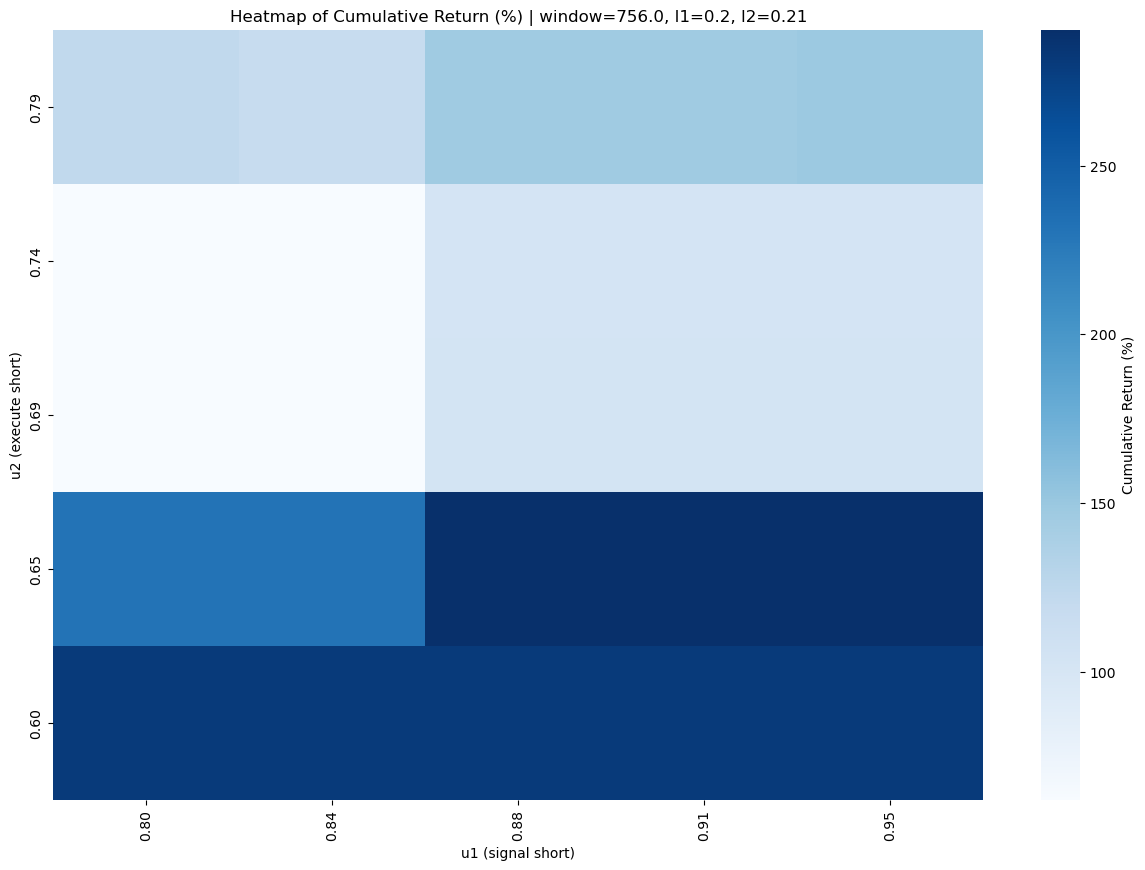

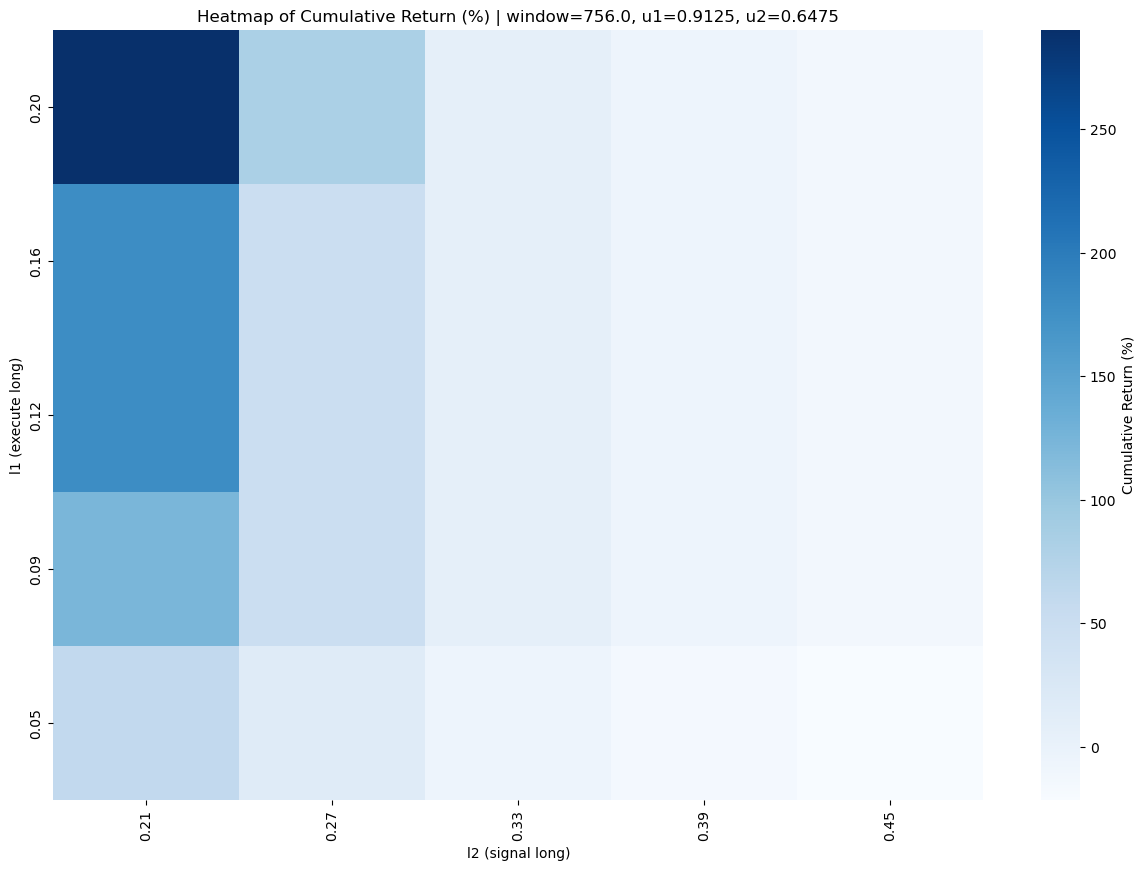

In [7]:
import seaborn as sns

# Fix best window, u2, l2 for u1 vs l1 heatmap
best_window = results_df.iloc[0]['window']

# u1 vs u2 heatmap (short side)
best_l1 = results_df.iloc[0]['l1']
best_l2 = results_df.iloc[0]['l2']

filtered_u1_u2 = results_df[
    (results_df['window'] == best_window) &
    (results_df['l1'] == best_l1) &
    (results_df['l2'] == best_l2)
]

hm_data = filtered_u1_u2.pivot(index='u2', columns='u1', values='train_cumret')

plt.figure(figsize=(15, 10))
plt.title(f'Heatmap of Cumulative Return (%) | window={best_window}, l1={best_l1}, l2={best_l2}')
ax = sns.heatmap(hm_data, cmap='Blues', cbar_kws={'label': 'Cumulative Return (%)'})
ax.invert_yaxis()
ax.set_xticks(np.arange(len(hm_data.columns)) + 0.5)
ax.set_xticklabels([f"{k:.2f}" for k in hm_data.columns], rotation=90)
ax.set_yticks(np.arange(len(hm_data.index)) + 0.5)
ax.set_yticklabels([f"{z:.2f}" for z in hm_data.index])
plt.xlabel('u1 (signal short)')
plt.ylabel('u2 (execute short)')
plt.show()

# l2 vs l1 heatmap (long side)
best_u1 = results_df.iloc[0]['u1']
best_u2 = results_df.iloc[0]['u2']

filtered_l2_l1 = results_df[
    (results_df['window'] == best_window) &
    (results_df['u1'] == best_u1) &
    (results_df['u2'] == best_u2)
]

hm_data = filtered_l2_l1.pivot(index='l1', columns='l2', values='train_cumret')

plt.figure(figsize=(15, 10))
plt.title(f'Heatmap of Cumulative Return (%) | window={best_window}, u1={best_u1}, u2={best_u2}')
ax = sns.heatmap(hm_data, cmap='Blues', cbar_kws={'label': 'Cumulative Return (%)'})
ax.invert_yaxis()
ax.set_xticks(np.arange(len(hm_data.columns)) + 0.5)
ax.set_xticklabels([f"{k:.2f}" for k in hm_data.columns], rotation=90)
ax.set_yticks(np.arange(len(hm_data.index)) + 0.5)
ax.set_yticklabels([f"{z:.2f}" for z in hm_data.index])
plt.xlabel('l2 (signal long)')
plt.ylabel('l1 (execute long)')
plt.show()

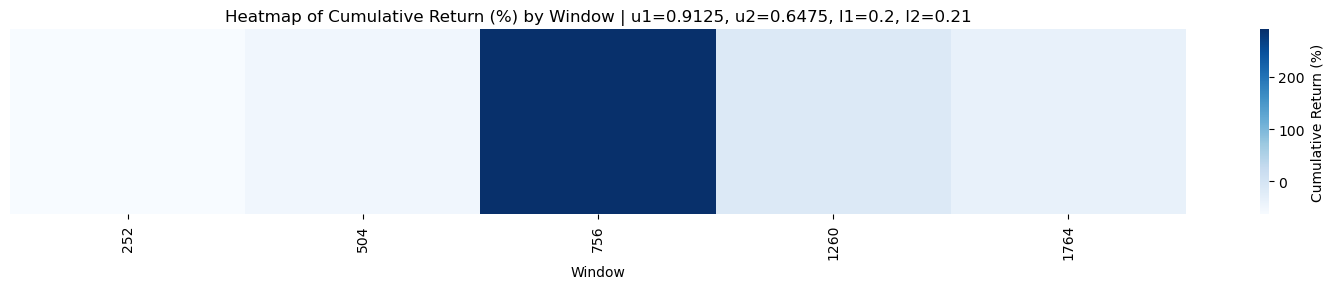

In [ ]:
# Windows heatmap for best u1, u2, l1, l2
filtered = results_df[
    (results_df['u1'] == best_u1) &
    (results_df['u2'] == best_u2) &
    (results_df['l1'] == best_l1) &
    (results_df['l2'] == best_l2)
].sort_values('window')

hm_data = filtered.set_index('window')[['train_cumret']].T

plt.figure(figsize=(15, 3))
plt.title(f'Heatmap of Cumulative Return (%) by Window | u1={best_u1}, u2={best_u2}, l1={best_l1}, l2={best_l2}')
ax = sns.heatmap(hm_data, cmap='Blues', cbar_kws={'label': 'Cumulative Return (%)'})
ax.set_xticks(np.arange(len(hm_data.columns)) + 0.5)
ax.set_xticklabels([f"{k}" for k in hm_data.columns], rotation=90)
ax.set_yticks([])
plt.xlabel('Window')
plt.tight_layout()
plt.show()

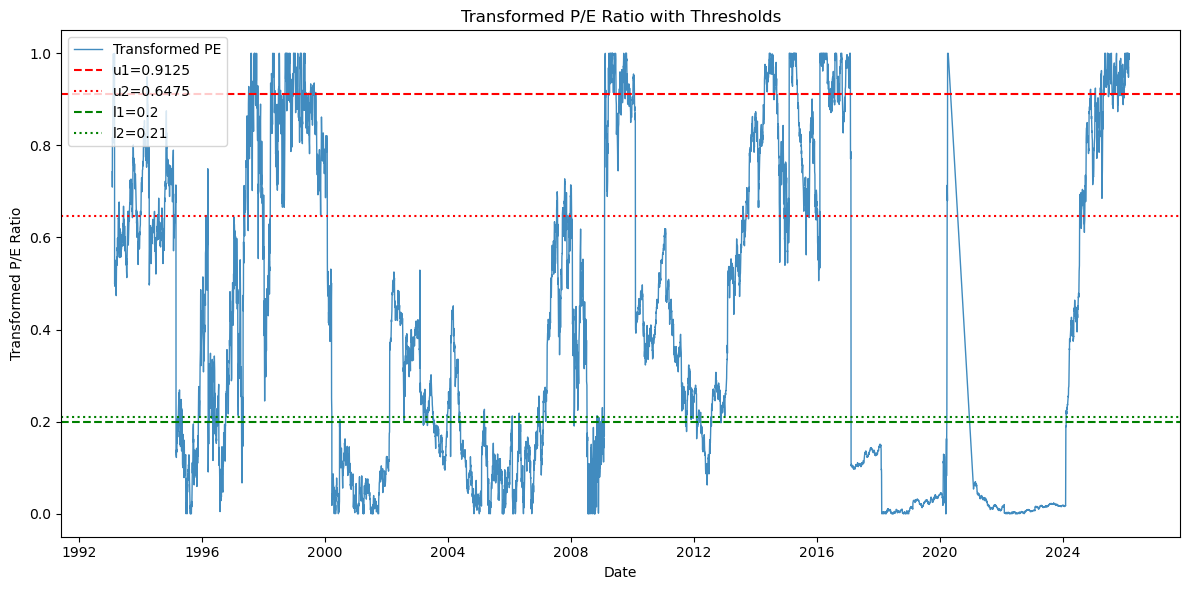

In [9]:
# Transformed PE plot with best thresholds u1, u2, l1, l2
plt.figure(figsize=(12,6))
plt.plot(energy_sector.index, energy_sector['transformed'], label='Transformed PE', alpha=0.85, lw=1)
plt.axhline(u1, color='red', linestyle='--', label=f'u1={u1}')
plt.axhline(u2, color='red', linestyle=':', label=f'u2={u2}')
plt.axhline(l1, color='green', linestyle='--', label=f'l1={l1}')
plt.axhline(l2, color='green', linestyle=':', label=f'l2={l2}')
plt.title('Transformed P/E Ratio with Thresholds')
plt.xlabel('Date')
plt.ylabel('Transformed P/E Ratio')
plt.legend()
plt.tight_layout()
plt.show()

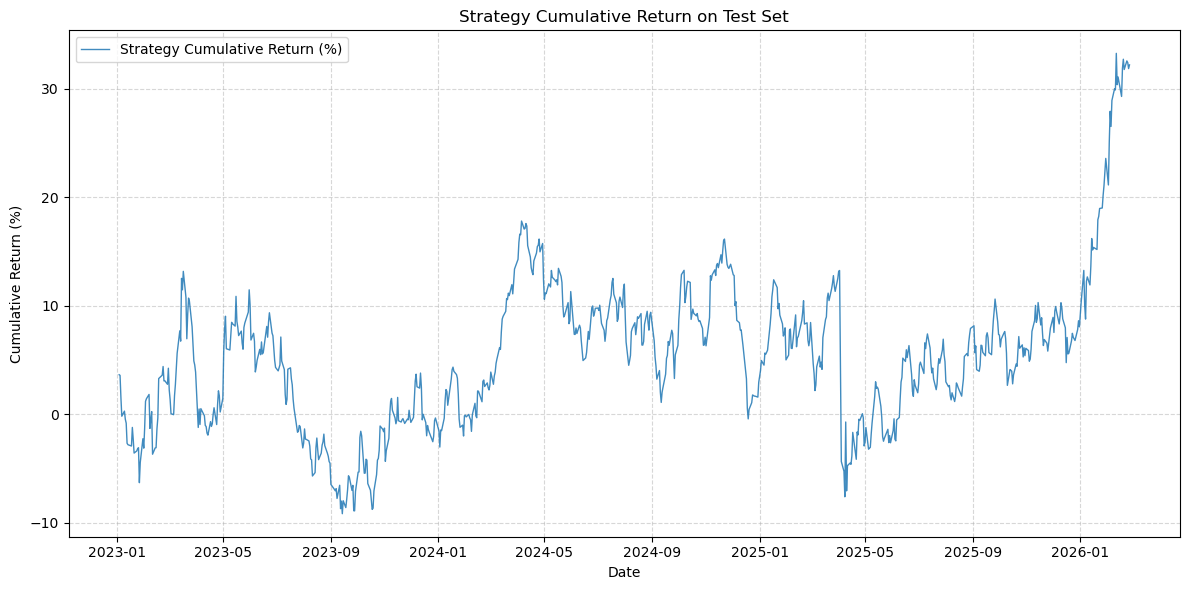

Cumulative Return on Test Set: 32.19%


In [10]:
# Applied best parameters to test set
strat_ret = run_strategy(energy_sector, window, u1, u2, l1, l2)
test_ret = strat_ret[strat_ret.index >= test_start].dropna()
cumret = (test_ret + 1).cumprod() - 1

plt.figure(figsize=(12,6))
plt.plot(cumret.index, cumret * 100, label='Strategy Cumulative Return (%)', alpha=0.85, lw=1)
plt.title('Strategy Cumulative Return on Test Set')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cumulative Return on Test Set: {cumret.iloc[-1] * 100:.2f}%")

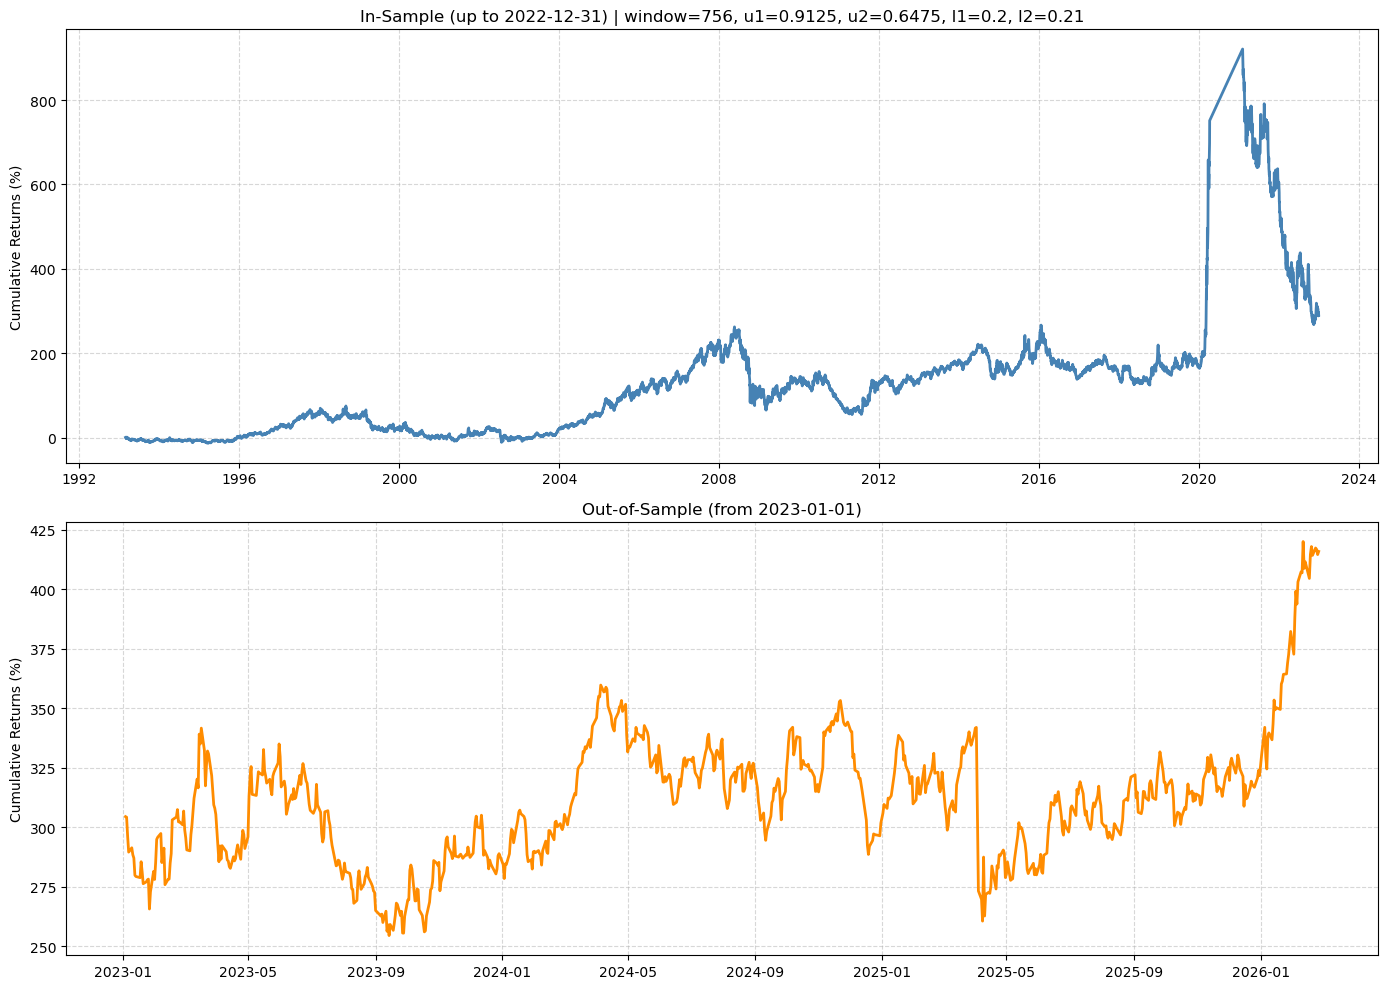

In [11]:
# Applied best parameters to full data and plot train vs test
strat_ret = run_strategy(energy_sector, window, u1, u2, l1, l2)
energy_sector['cumret_best'] = ((strat_ret + 1).cumprod() - 1) * 100

train = energy_sector.loc[energy_sector.index <= train_end]
test  = energy_sector.loc[energy_sector.index >= test_start]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(train.index, train['cumret_best'], color='steelblue', lw=2)
axes[0].set_title(f'In-Sample (up to {train_end}) | window={window}, u1={u1}, u2={u2}, l1={l1}, l2={l2}')
axes[0].set_ylabel('Cumulative Returns (%)')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(test.index, test['cumret_best'], color='darkorange', lw=2)
axes[1].set_title(f'Out-of-Sample (from {test_start})')
axes[1].set_ylabel('Cumulative Returns (%)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()